In [77]:
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict
import numpy as np
import copy
from collections import defaultdict, deque
import pickle
import random
from tqdm import trange
import matplotlib.pyplot as plt

In [78]:
Operator = Optional[str]  # '+', '-', 'x', '/' or None

@dataclass
class Piece:
    player: int  # 1 = Blue, -1 = Red
    value: int
    dama: bool = False

    def __repr__(self):
        # Convert B to blue emoji and R to red emoji for better visualization
        p = "🔵" if self.player == 1 else "🔴"
        val = f"{self.value:+d}" if self.value >= 0 else str(self.value)
        return f"{p}{'D' if self.dama else ''}{val}"
    
    
    def copy(self):
        return Piece(self.player, self.value, self.dama)

@dataclass
class Move:
    path: List[Tuple[int, int]]            # sequence of positions traversed
    captures: List[Tuple[int, int]]        # list of captured piece positions
    promotes: bool = False                 # whether the move results in promotion
    score_gain: int = 0                    # arithmetic reward from the move
    is_dama_capture: bool = False          # whether move made by dama
    is_multi_jump: bool = False            # whether multiple captures occurred

    def __repr__(self):
        cap_str = f" x{len(self.captures)}" if self.captures else ""
        promo = " (promo)" if self.promotes else ""
        return f"{self.path}{cap_str}{promo} +{self.score_gain}"



In [79]:
class DamathEnv:
    def __init__(self, rows=8, cols=8, operator_pattern=None):
        self.R = rows
        self.C = cols
        assert rows==8 and cols==8, "Currently implemented for 8x8 boards."
        
        # Operators on playable squares. Default pattern similar to provided image if None.
        if operator_pattern is None:
            operator_pattern = self.default_operator_board()
        self.op_board = operator_pattern
        
        # Piece board: dict (r,c)->Piece
        self.pieces: Dict[Tuple[int,int], Piece] = {}
        
        # Scores cumulative per player
        self.scores = {1: 0.0, -1: 0.0}
        self.to_move = 1  # 1 starts (blue on top)
        self.history_states = deque(maxlen=50)  # for repetition detection
        
        # Reward configuration for immediate rewards during gameplay
        self.reward_config = {
            'capture_multiplier': 1.0,      # scale immediate capture score
            'promotion_bonus': 10.0,        # bonus for promoting to dama
            'dama_bonus': 5.0,              # bonus for capturing dama pieces
            'piece_loss_penalty': -5.0,     # penalty for losing a piece (not currently used)
            'dama_loss_penalty': -15.0,     # penalty for losing a dama (not currently used)
        }
        
        # initialize sample starting board
        self.init_default_integer_setup()

    def default_operator_board(self):
        """Create operator layout (8x8) using a repeating pattern."""
        ops = ['x','/','-','+']  # cycle
        board = [[None for _ in range(self.C)] for __ in range(self.R)]
        for r in range(self.R):
            for c in range(self.C):
                if (r + c) % 2 == 1:
                    board[r][c] = ops[(r + 2*c) % len(ops)]
                else:
                    board[r][c] = None
        return board

    def init_default_integer_setup(self):
        """Initialize pieces with default values."""
        self.pieces = {}
        blue_values = [
            [-11, 8, -5, 2],
            [0, -3, 10, -7],
            [-9, 6, -1, 4],
        ]
        red_values = [
            [4, -1, 6, -9],
            [-7, 10, -3, 0],
            [2, -5, 8, -11]
        ]
        
        def playable_positions_on_row(r):
            return [c for c in range(self.C) if (r+c)%2==1]
        
        # Blue top 3 rows
        for i, r in enumerate(range(0,3)):
            cols = playable_positions_on_row(r)
            vals = blue_values[i]
            for j, c in enumerate(cols[:len(vals)]):
                self.pieces[(r,c)] = Piece(player=1, value=vals[j], dama=False)
        
        # Red bottom 3 rows
        for i, r in enumerate(range(5,8)):
            cols = playable_positions_on_row(r)
            vals = red_values[i-0] if i < len(red_values) else []
            for j, c in enumerate(cols[:len(vals)]):
                self.pieces[(r,c)] = Piece(player=-1, value=vals[j], dama=False)
        
        self.scores = {1:0.0, -1:0.0}
        self.to_move = 1
        self.history_states.clear()
        self.record_state()

    def copy(self):
        newenv = DamathEnv(self.R, self.C)
        newenv.op_board = copy.deepcopy(self.op_board)
        newenv.pieces = {k: v.copy() for k,v in self.pieces.items()}
        newenv.scores = dict(self.scores)
        newenv.to_move = self.to_move
        newenv.history_states = copy.deepcopy(self.history_states)
        newenv.reward_config = dict(self.reward_config)
        return newenv

    def in_bounds(self, r,c):
        return 0 <= r < self.R and 0 <= c < self.C

    def is_playable(self, r,c):
        return self.in_bounds(r,c) and ((r+c)%2==1)

    def get_piece(self, r,c) -> Optional[Piece]:
        return self.pieces.get((r,c))

    def remove_piece(self, r,c):
        if (r,c) in self.pieces:
            del self.pieces[(r,c)]

    def move_piece(self, from_rc, to_rc):
        p = self.pieces.pop(from_rc)
        self.pieces[to_rc] = p
        return p

    def record_state(self):
        """Record state for repetition detection."""
        items = tuple(sorted([ (pos, piece.player, piece.value, piece.dama) 
                               for pos,piece in self.pieces.items() ]))
        key = (self.to_move, items)
        self.history_states.append(key)

    def op_at(self, r,c):
        """Get operator at position (r,c)."""
        if not self.is_playable(r,c):
            return None
        return self.op_board[r][c]

    def apply_operator(self, op: str, a: int, b: int):
        """Apply operator to two numbers."""
        if op == '+':
            return a + b
        if op == '-':
            return a - b
        if op == 'x' or op == 'X' or op == '*':
            return a * b
        if op == '/':
            if b == 0:
                return 0
            return int(a / b)
        raise ValueError("Unknown op "+str(op))

    def generate_all_moves(self, player:int):
        """Generate all legal moves for player."""
        capture_moves = []
        for pos, piece in list(self.pieces.items()):
            if piece.player != player: 
                continue
            caps = self._generate_captures_from(pos, piece)
            capture_moves.extend(caps)
        
        if len(capture_moves) > 0:
            max_cap = max(len(m.captures) for m in capture_moves)
            maxcap_moves = [m for m in capture_moves if len(m.captures)==max_cap]
            if any(self.pieces[m.path[0]].dama for m in maxcap_moves):
                maxcap_moves = [m for m in maxcap_moves if self.pieces[m.path[0]].dama]
            for m in maxcap_moves:
                m.score_gain = self._compute_move_score(m, player)
            return maxcap_moves
        
        simple_moves = []
        for pos, piece in list(self.pieces.items()):
            if piece.player != player: 
                continue
            sms = self._generate_simple_from(pos, piece)
            simple_moves.extend(sms)
        
        for m in simple_moves:
            m.score_gain = 0.0
        return simple_moves

    def _generate_simple_from(self, pos, piece:Piece):
        """Generate simple (non-capture) moves."""
        r,c = pos
        moves = []
        
        if piece.dama:
            for dr,dc in [(-1,-1),(-1,1),(1,-1),(1,1)]:
                step=1
                while True:
                    nr = r + dr*step
                    nc = c + dc*step
                    if not self.in_bounds(nr,nc) or not self.is_playable(nr,nc): 
                        break
                    if (nr,nc) in self.pieces: 
                        break
                    path = [(r,c),(nr,nc)]
                    promotes = self._check_promotion(nr, piece.player)
                    moves.append(Move(path=path, captures=[], promotes=promotes))
                    step += 1
        else:
            dr = 1 if piece.player==1 else -1
            for dc in (-1,1):
                nr = r + dr
                nc = c + dc
                if not self.in_bounds(nr,nc) or not self.is_playable(nr,nc): 
                    continue
                if (nr,nc) in self.pieces: 
                    continue
                path=[(r,c),(nr,nc)]
                promotes = self._check_promotion(nr, piece.player)
                moves.append(Move(path=path, captures=[], promotes=promotes))
        
        return moves

    def _generate_captures_from(self, pos, piece:Piece):
        """Generate all capture sequences from position."""
        results = []
        r,c = pos

        if piece.dama:
            for dr,dc in [(-1,-1),(-1,1),(1,-1),(1,1)]:
                step=1
                while True:
                    mr = r + dr*step
                    mc = c + dc*step
                    if not self.in_bounds(mr,mc) or not self.is_playable(mr,mc): 
                        break
                    if (mr,mc) in self.pieces:
                        target = self.pieces[(mr,mc)]
                        if target.player == piece.player:
                            break
                        land_step = 1
                        while True:
                            lr = mr + dr*land_step
                            lc = mc + dc*land_step
                            if not self.in_bounds(lr,lc) or not self.is_playable(lr,lc): 
                                break
                            if (lr,lc) in self.pieces: 
                                break
                            new_env = self.copy()
                            captured_piece = new_env.pieces.pop((mr,mc))
                            moved_piece = new_env.pieces.pop((r,c))
                            new_env.pieces[(lr,lc)] = moved_piece
                            further = new_env._generate_captures_from((lr,lc), moved_piece)
                            
                            if len(further)==0:
                                m = Move(path=[(r,c),(lr,lc)], captures=[(mr,mc,captured_piece)], promotes=False)
                                results.append(m)
                            else:
                                for fm in further:
                                    m = Move(path=[(r,c)] + fm.path, captures=[(mr,mc,captured_piece)] + fm.captures, promotes=False)
                                    results.append(m)
                            land_step += 1
                        break
                    else:
                        step += 1
        else:
            for dr,dc in [(-1,-1),(-1,1),(1,-1),(1,1)]:
                ar = r + dr
                ac = c + dc
                lr = r + 2*dr
                lc = c + 2*dc
                if not self.in_bounds(ar,ac) or not self.is_playable(ar,ac): 
                    continue
                if (ar,ac) not in self.pieces: 
                    continue
                if self.pieces[(ar,ac)].player == piece.player: 
                    continue
                if not self.in_bounds(lr,lc) or not self.is_playable(lr,lc): 
                    continue
                if (lr,lc) in self.pieces: 
                    continue
                
                new_env = self.copy()
                captured_piece = new_env.pieces.pop((ar,ac))
                moved_piece = new_env.pieces.pop((r,c))
                new_env.pieces[(lr,lc)] = moved_piece
                further = new_env._generate_captures_from((lr,lc), moved_piece)
                
                if len(further)==0:
                    m = Move(path=[(r,c),(lr,lc)], captures=[(ar,ac,captured_piece)], promotes=self._check_promotion(lr,piece.player))
                    results.append(m)
                else:
                    for fm in further:
                        m = Move(path=[(r,c)] + fm.path, captures=[(ar,ac,captured_piece)] + fm.captures, promotes=self._check_promotion(fm.path[-1][0], piece.player))
                        results.append(m)
        
        uniq = {}
        for m in results:
            key = (tuple(m.path), tuple((r,c,cp.value) for r,c,cp in m.captures))
            if key not in uniq or len(uniq[key].captures) < len(m.captures):
                uniq[key] = m
        return list(uniq.values())

    def _compute_move_score(self, move:Move, mover_player:int):
        """Compute arithmetic score gain for a capture move."""
        total = 0.0
        mover_start = move.path[0]
        mover_piece = self.pieces.get(mover_start)
        mover_is_dama = mover_piece.dama if mover_piece else False
        mover_value = mover_piece.value if mover_piece else 0
        
        for i, (cap_r,cap_c,cap_piece) in enumerate(move.captures):
            landing = move.path[1+i] if len(move.path) > 1+i else move.path[-1]
            op = self.op_at(*landing)
            base = self.apply_operator(op, mover_value, cap_piece.value)
            
            mult = 1
            if mover_is_dama and cap_piece.dama:
                mult = 4
            elif mover_is_dama:
                mult = 2
            elif cap_piece.dama:
                mult = 2
            total += base * mult
        return total

    def _check_promotion(self, r, player):
        """Check if piece should be promoted to dama."""
        if player==1 and r==self.R-1: 
            return True
        if player==-1 and r==0: 
            return True
        return False

    def apply_move_with_penalties(self, move: "Move", verbose=False):
        """
        Apply move and return immediate reward WITH penalties for opponent.
        
        This version returns a dict with rewards for both players:
        - Current player: gets reward for captures/promotions
        - Other player: gets penalty if their pieces were captured
        
        Use this if you want to apply penalties in the training loop.
        """
        player = self.to_move
        opponent = -player
        rewards = {player: 0.0, opponent: 0.0}

        if len(move.captures) == 0:
            # Simple move
            frm, to = move.path[0], move.path[-1]
            piece = self.pieces.pop(frm)
            self.pieces[to] = piece

            if self._check_promotion(to[0], piece.player) and not piece.dama:
                piece.dama = True
                rewards[player] += self.reward_config['promotion_bonus']

        else:
            # Capture move
            frm = move.path[0]
            mover = self.pieces.pop(frm)
            current_pos = frm
            total_gain = 0.0

            for i, (cap_r, cap_c, cap_piece_snapshot) in enumerate(move.captures):
                landing = move.path[1 + i] if 1 + i < len(move.path) else move.path[-1]
                op = self.op_at(*landing)
                captured_piece = self.pieces.pop((cap_r, cap_c))
                base = self.apply_operator(op, mover.value, captured_piece.value)

                mult = 1
                if mover.dama and captured_piece.dama:
                    mult = 4
                elif mover.dama or captured_piece.dama:
                    mult = 2

                total_gain += base * mult
                
                # Mover's reward for capture
                if captured_piece.dama:
                    rewards[player] += self.reward_config['dama_bonus']
                
                # Opponent's penalty for being captured
                if captured_piece.dama:
                    rewards[opponent] += self.reward_config['dama_loss_penalty']
                else:
                    rewards[opponent] += self.reward_config['piece_loss_penalty']
                
                current_pos = landing

            self.pieces[current_pos] = mover
            if self._check_promotion(current_pos[0], mover.player) and not mover.dama:
                mover.dama = True
                rewards[player] += self.reward_config['promotion_bonus']
            
            self.scores[mover.player] += total_gain
            rewards[player] += total_gain * self.reward_config['capture_multiplier']

        self.to_move *= -1
        self.record_state()

        if verbose:
            print(f"[Player {player}] captured, rewards: P1={rewards[1]:+.2f}, P2={rewards[-1]:+.2f}")
        
        return rewards  # Returns dict: {1: reward_p1, -1: reward_p2}

    def legal_moves_exist(self, player:int):
        return len(self.generate_all_moves(player))>0

    def game_over(self):
        """Check if game is over."""
        if not self.legal_moves_exist(self.to_move):
            return True
        players_present = set(p.player for p in self.pieces.values())
        if len(players_present) <= 1:
            return True
        hist = list(self.history_states)
        if len(hist) >= 8:
            counts = defaultdict(int)
            for h in hist:
                counts[h] += 1
                if counts[h] >= 4:
                    return True
        return False

    def final_scores_and_winner(self):
        """Compute final scores and determine winner."""
        final_scores = dict(self.scores)
        for (r,c), piece in self.pieces.items():
            val = piece.value * (2 if piece.dama else 1)
            final_scores[piece.player] += val
        
        if final_scores[1] > final_scores[-1]:
            winner = 1
        elif final_scores[1] < final_scores[-1]:
            winner = -1
        else:
            winner = 0
        return final_scores, winner

    def print_board(self):
        """Print current board state."""
        grid = [[" ." for _ in range(self.C)] for __ in range(self.R)]
        for y in range(self.R):
            for x in range(self.C):
                if not self.is_playable(y, x):
                    grid[y][x] = "##"
                else:
                    op = self.op_at(y, x)
                    grid[y][x] = f" {op}"
        
        for (y, x), piece in self.pieces.items():
            sym = '🔵' if piece.player == 1 else '🔴'
            if piece.dama:
                sym += 'K'
            grid[y][x] = f"{sym}{piece.value:02d}" if piece.value >= 0 else f"{sym}{piece.value}"

        print("\n     " + " ".join([f"{x:>4}" for x in range(self.C)]))
        print("     " + "----" * self.C)

        for y in reversed(range(self.R)):
            row_str = " ".join(f"{cell:>4}" for cell in grid[y])
            print(f"{y:>2} | {row_str} | {y:>2}")

        print("     " + "----" * self.C)
        print("     " + " ".join([f"{x:>4}" for x in range(self.C)]))
        
    def get_state_hash(self):
        """Get hashable state representation."""
        items = tuple(sorted([(pos, p.player, p.value, p.dama) 
                        for pos, p in self.pieces.items()]))
        return (self.to_move, items)
    
    def set_reward_config(self, config_dict: dict):
        """Update reward configuration."""
        self.reward_config.update(config_dict)

In [80]:
operator_pattern_official = [
    ['x', '+', '/', '-', '-', '/', '+', 'x'],
    ['-', '/', '+', 'x', 'x', '+', '/', '-'],
    ['-', '/', '+', 'x', 'x', '+', '/', '-'],
    ['x', '+', '/', '-', '-', '/', '+', 'x'],
    ['x', '+', '/', '-', '-', '/', '+', 'x'],
    ['-', '/', '+', 'x', 'x', '+', '/', '-'],
    ['-', '/', '+', 'x', 'x', '+', '/', '-'],
    ['x', '/', '/', '-', '-', '/', '+', 'x']
]

In [81]:
# Operator layout: (y, x) format
# y=0 is bottom row, y=7 is top row

env = DamathEnv(rows = 8, cols = 8, operator_pattern=operator_pattern_official)
env.print_board()
moves = env.generate_all_moves(env.to_move)
print("\nAvailable moves for player", env.to_move, "->", len(moves))
for move in moves:
    start = move.path[0]
    end = move.path[-1]
    piece = env.pieces.get(start, None)
    if piece:
        piece_type = "Dama" if piece.dama else "Regular"
        # Swap (y, x) to (x, y) for readability
        print(f"{piece_type} {piece.value:+d} at ({start[1]}, {start[0]}) -> ({end[1]}, {end[0]}) | ΔScore: {move.score_gain:+.1f}")
    else:
        print(f"Unknown piece at ({start[1]}, {start[0]}) -> ({end[1]}, {end[0]}) | ΔScore: {move.score_gain:+.1f}")




        0    1    2    3    4    5    6    7
     --------------------------------
 7 |  🔴02   ##  🔴-5   ##  🔴08   ## 🔴-11   ## |  7
 6 |   ##  🔴-7   ##  🔴10   ##  🔴-3   ##  🔴00 |  6
 5 |  🔴04   ##  🔴-1   ##  🔴06   ##  🔴-9   ## |  5
 4 |   ##    +   ##    -   ##    /   ##    x |  4
 3 |    x   ##    /   ##    -   ##    +   ## |  3
 2 |   ##  🔵-9   ##  🔵06   ##  🔵-1   ##  🔵04 |  2
 1 |  🔵00   ##  🔵-3   ##  🔵10   ##  🔵-7   ## |  1
 0 |   ## 🔵-11   ##  🔵08   ##  🔵-5   ##  🔵02 |  0
     --------------------------------
        0    1    2    3    4    5    6    7

Available moves for player 1 -> 7
Regular -9 at (1, 2) -> (0, 3) | ΔScore: +0.0
Regular -9 at (1, 2) -> (2, 3) | ΔScore: +0.0
Regular +6 at (3, 2) -> (2, 3) | ΔScore: +0.0
Regular +6 at (3, 2) -> (4, 3) | ΔScore: +0.0
Regular -1 at (5, 2) -> (4, 3) | ΔScore: +0.0
Regular -1 at (5, 2) -> (6, 3) | ΔScore: +0.0
Regular +4 at (7, 2) -> (6, 3) | ΔScore: +0.0


In [82]:
# Print empty board with no pieces, just operators
env_empty = DamathEnv(rows = 8, cols = 8, operator_pattern=operator_pattern_official)
env_empty.pieces = {}  # clear pieces
env_empty.print_board()


        0    1    2    3    4    5    6    7
     --------------------------------
 7 |    x   ##    /   ##    -   ##    +   ## |  7
 6 |   ##    /   ##    x   ##    +   ##    - |  6
 5 |    -   ##    +   ##    x   ##    /   ## |  5
 4 |   ##    +   ##    -   ##    /   ##    x |  4
 3 |    x   ##    /   ##    -   ##    +   ## |  3
 2 |   ##    /   ##    x   ##    +   ##    - |  2
 1 |    -   ##    +   ##    x   ##    /   ## |  1
 0 |   ##    +   ##    -   ##    /   ##    x |  0
     --------------------------------
        0    1    2    3    4    5    6    7


In [83]:
class QLearner:
    def __init__(self, learning_rate=0.01, gamma=0.9, epsilon=0.2):
        """
        Initialize Q-Learning agent.
        
        Args:
            learning_rate: Step size for Q-value updates (0.01-0.1 typical)
            gamma: Discount factor for future rewards (0.9-0.99 typical)
            epsilon: Exploration rate for epsilon-greedy policy (0.1-0.3 typical)
        """
        self.Q = defaultdict(lambda: defaultdict(float))
        self.learning_rate = learning_rate
        self.gamma = gamma
        self.epsilon = epsilon
        self.update_count = 0  # Track number of updates for debugging
 
    def get_q_value(self, state, action):
        """Get Q-value for a state-action pair."""
        state_key = state
        action_key = self._move_to_key(action)
        return self.Q[state_key][action_key]

    def choose_action(self, env, moves):
        """
        Choose action using epsilon-greedy policy.
        
        With probability epsilon: random exploration
        Otherwise: greedy (best Q-value)
        
        Args:
            env: Game environment
            moves: List of legal moves
            
        Returns:
            Selected move
        """
        if not moves:
            return None
        
        # Exploration: random action
        if random.random() < self.epsilon:
            return random.choice(moves)
        
        # Exploitation: greedy action
        state = env.get_state_hash()
        q_values = [(self.get_q_value(state, m), m) for m in moves]
        max_q = max(q_values, key=lambda x: x[0])[0]
        best_moves = [m for q, m in q_values if q == max_q]
        return random.choice(best_moves)

    def update_q_value(self, state, action, target):
        """
        Update Q-value using Q-learning update rule:
        Q(s,a) ← Q(s,a) + α(target - Q(s,a))
        
        Where target is pre-computed as:
        - Terminal: immediate_reward + final_reward_bonus
        - Non-terminal: immediate_reward + γ*max_a'Q(s',a')
        
        Args:
            state: Current state
            action: Action taken
            target: Target Q-value (should be pre-calculated in training loop)
        """
        state_key = state
        action_key = self._move_to_key(action)
        
        current_q = self.Q[state_key][action_key]
        td_error = target - current_q
        self.Q[state_key][action_key] = current_q + self.learning_rate * td_error
        self.update_count += 1

    def _move_to_key(self, move):
        """
        Convert Move object to hashable key for Q-table indexing.
        
        Key consists of:
        - path: tuple of positions the piece moves through
        - captures: tuple of captured positions (with values for uniqueness)
        """
        if move is None:
            return None
        return (tuple(move.path), tuple((r, c) for r, c, _ in move.captures))

    def get_max_q_value(self, state, moves):
        """
        Get maximum Q-value across all available actions.
        Useful for bootstrapping in training loop.
        
        Args:
            state: Current state
            moves: List of available moves
            
        Returns:
            Maximum Q-value, or 0.0 if no moves
        """
        if not moves:
            return 0.0
        q_values = [self.get_q_value(state, m) for m in moves]
        return max(q_values) if q_values else 0.0

    def set_epsilon(self, epsilon):
        """Adjust exploration rate (for epsilon decay during training)."""
        self.epsilon = epsilon

    def set_learning_rate(self, learning_rate):
        """Adjust learning rate (for learning rate decay during training)."""
        self.learning_rate = learning_rate

    def get_stats(self):
        """Return training statistics."""
        total_states = len(self.Q)
        total_entries = sum(len(actions) for actions in self.Q.values())
        return {
            'total_states': total_states,
            'total_q_entries': total_entries,
            'total_updates': self.update_count,
            'avg_q_per_state': total_entries / total_states if total_states > 0 else 0
        }

    def save(self, path):
        """Save Q-table to file."""
        with open(path, 'wb') as f:
            pickle.dump({
                'Q': dict(self.Q),
                'learning_rate': self.learning_rate,
                'gamma': self.gamma,
                'epsilon': self.epsilon,
                'update_count': self.update_count
            }, f)
        print(f"Agent saved to {path}")

    def load(self, path):
        """Load Q-table from file."""
        with open(path, 'rb') as f:
            data = pickle.load(f)
            self.Q = defaultdict(lambda: defaultdict(float), data['Q'])
            self.learning_rate = data.get('learning_rate', self.learning_rate)
            self.gamma = data.get('gamma', self.gamma)
            self.epsilon = data.get('epsilon', self.epsilon)
            self.update_count = data.get('update_count', 0)
        print(f"Agent loaded from {path}")

    def reset_q_table(self):
        """Reset Q-table to initial state (useful for retraining)."""
        self.Q = defaultdict(lambda: defaultdict(float))
        self.update_count = 0
        print("Q-table reset")

In [84]:
class MetricsTracker:
    """Track comprehensive metrics for Q-learning game episodes"""
    
    def __init__(self):
        self.reset()
    
    def reset(self):
        """Reset all metrics"""
        self.episodes = []
        self.p1_wins = 0
        self.p2_wins = 0
        self.draws = 0
        self.score_diffs = []
        self.episode_lengths = []
        self.rewards_p1 = []
        self.rewards_p2 = []
        self.final_scores_p1 = []
        self.final_scores_p2 = []
    
    def record_episode(self, winner: int, final_scores: Dict, episode_length: int, 
                      final_reward_p1: float, final_reward_p2: float):
        """Record metrics for a completed episode"""
        # Track wins
        if winner == 1:
            self.p1_wins += 1
        elif winner == -1:
            self.p2_wins += 1
        else:
            self.draws += 1
        
        # Track scores
        p1_score = final_scores.get(1, 0.0)
        p2_score = final_scores.get(-1, 0.0)
        self.final_scores_p1.append(p1_score)
        self.final_scores_p2.append(p2_score)
        
        # Track score differential (absolute value)
        score_diff = abs(p1_score - p2_score)
        self.score_diffs.append(score_diff)
        
        # Track episode length
        self.episode_lengths.append(episode_length)
        
        # Track rewards
        self.rewards_p1.append(final_reward_p1)
        self.rewards_p2.append(final_reward_p2)
        
        # Store episode data
        self.episodes.append({
            'episode': len(self.episodes) + 1,
            'winner': winner,
            'p1_score': p1_score,
            'p2_score': p2_score,
            'score_diff': score_diff,
            'length': episode_length,
            'reward_p1': final_reward_p1,
            'reward_p2': final_reward_p2
        })
    
    def get_summary(self) -> Dict:
        """Get comprehensive summary of all metrics"""
        total_games = self.p1_wins + self.p2_wins + self.draws
        
        return {
            'total_episodes': len(self.episodes),
            'p1_cumulative_wins': self.p1_wins,
            'p2_cumulative_wins': self.p2_wins,
            'draws': self.draws,
            'p1_winrate': (self.p1_wins / total_games * 100) if total_games > 0 else 0.0,
            'p2_winrate': (self.p2_wins / total_games * 100) if total_games > 0 else 0.0,
            'avg_score_diff': np.mean(self.score_diffs) if self.score_diffs else 0.0,
            'avg_episode_length': np.mean(self.episode_lengths) if self.episode_lengths else 0.0,
            'p1_mean_abs_reward': np.mean(np.abs(self.rewards_p1)) if self.rewards_p1 else 0.0,
            'p2_mean_abs_reward': np.mean(np.abs(self.rewards_p2)) if self.rewards_p2 else 0.0,
            'p1_avg_score': np.mean(self.final_scores_p1) if self.final_scores_p1 else 0.0,
            'p2_avg_score': np.mean(self.final_scores_p2) if self.final_scores_p2 else 0.0
        }
    
    def print_summary(self):
        """Print formatted summary of metrics"""
        summary = self.get_summary()
        print("="*60)
        print("TRAINING METRICS SUMMARY")
        print("="*60)
        print(f"Total Episodes: {summary['total_episodes']}")
        print(f"\nCumulative Wins:")
        print(f"  Player 1 (Blue): {summary['p1_cumulative_wins']} ({summary['p1_winrate']:.2f}%)")
        print(f"  Player 2 (Red):  {summary['p2_cumulative_wins']} ({summary['p2_winrate']:.2f}%)")
        print(f"  Draws: {summary['draws']}")
        print(f"\nScore Metrics:")
        print(f"  Avg Score Differential (Absolute): {summary['avg_score_diff']:.2f}")
        print(f"  P1 Avg Final Score: {summary['p1_avg_score']:.2f}")
        print(f"  P2 Avg Final Score: {summary['p2_avg_score']:.2f}")
        print(f"\nEpisode Metrics:")
        print(f"  Avg Episode Length: {summary['avg_episode_length']:.2f} moves")
        print(f"\nReward Metrics:")
        print(f"  P1 Mean Absolute Reward: {summary['p1_mean_abs_reward']:.4f}")
        print(f"  P2 Mean Absolute Reward: {summary['p2_mean_abs_reward']:.4f}")
        print("="*60)
    
    def plot_metrics(self, window: int = 100):
        """Plot comprehensive metrics with moving averages"""
        if len(self.episodes) < 2:
            print("Not enough episodes to plot")
            return
        
        fig, axes = plt.subplots(3, 2, figsize=(15, 12))
        fig.suptitle('Q-Learning Metrics - Damath', fontsize=16, fontweight='bold')
        
        episodes = list(range(1, len(self.episodes) + 1))
        
        # 1. Cumulative Win Rate
        p1_cumulative_wins = np.cumsum([1 if ep['winner'] == 1 else 0 for ep in self.episodes])
        p2_cumulative_wins = np.cumsum([1 if ep['winner'] == -1 else 0 for ep in self.episodes])
        total_games = np.arange(1, len(episodes) + 1)
        p1_winrate = (p1_cumulative_wins / total_games) * 100
        p2_winrate = (p2_cumulative_wins / total_games) * 100
        
        axes[0, 0].plot(episodes, p1_winrate, label='P1 (Blue)', alpha=0.7, linewidth=2, color='blue')
        axes[0, 0].plot(episodes, p2_winrate, label='P2 (Red)', alpha=0.7, linewidth=2, color='red')
        axes[0, 0].axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50%')
        axes[0, 0].set_title('Cumulative Win Rate by P1 and P2', fontweight='bold')
        axes[0, 0].set_xlabel('Episode')
        axes[0, 0].set_ylabel('Win Rate (%)')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # 2. Score Differential (Absolute Value)
        axes[0, 1].plot(episodes, self.score_diffs, alpha=0.3, label='Score Diff', color='gray')
        if len(self.score_diffs) >= window:
            moving_avg = np.convolve(self.score_diffs, np.ones(window)/window, mode='valid')
            axes[0, 1].plot(range(window, len(episodes) + 1), moving_avg, 
                           label=f'{window}-Episode MA', linewidth=2, color='purple')
        axes[0, 1].set_title('Score Differential (Absolute Value)', fontweight='bold')
        axes[0, 1].set_xlabel('Episode')
        axes[0, 1].set_ylabel('|Score Diff|')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # 3. Average Episode Length
        axes[1, 0].plot(episodes, self.episode_lengths, alpha=0.3, label='Length', color='gray')
        if len(self.episode_lengths) >= window:
            moving_avg = np.convolve(self.episode_lengths, np.ones(window)/window, mode='valid')
            axes[1, 0].plot(range(window, len(episodes) + 1), moving_avg, 
                           label=f'{window}-Episode MA', linewidth=2, color='green')
        axes[1, 0].set_title('Episode Length (AvgLength)', fontweight='bold')
        axes[1, 0].set_xlabel('Episode')
        axes[1, 0].set_ylabel('Number of Moves')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # 4. Final Scores
        axes[1, 1].plot(episodes, self.final_scores_p1, alpha=0.3, label='P1 (Blue)', color='blue')
        axes[1, 1].plot(episodes, self.final_scores_p2, alpha=0.3, label='P2 (Red)', color='red')
        if len(self.final_scores_p1) >= window:
            p1_ma = np.convolve(self.final_scores_p1, np.ones(window)/window, mode='valid')
            p2_ma = np.convolve(self.final_scores_p2, np.ones(window)/window, mode='valid')
            axes[1, 1].plot(range(window, len(episodes) + 1), p1_ma, 
                           label=f'P1 {window}-MA', linewidth=2, color='darkblue')
            axes[1, 1].plot(range(window, len(episodes) + 1), p2_ma, 
                           label=f'P2 {window}-MA', linewidth=2, color='darkred')
        axes[1, 1].set_title('Final Scores', fontweight='bold')
        axes[1, 1].set_xlabel('Episode')
        axes[1, 1].set_ylabel('Score')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        # 5. Mean Absolute Rewards
        abs_rewards_p1 = np.abs(self.rewards_p1)
        abs_rewards_p2 = np.abs(self.rewards_p2)
        axes[2, 0].plot(episodes, abs_rewards_p1, alpha=0.3, label='P1 (Blue)', color='blue')
        axes[2, 0].plot(episodes, abs_rewards_p2, alpha=0.3, label='P2 (Red)', color='red')
        if len(abs_rewards_p1) >= window:
            p1_ma = np.convolve(abs_rewards_p1, np.ones(window)/window, mode='valid')
            p2_ma = np.convolve(abs_rewards_p2, np.ones(window)/window, mode='valid')
            axes[2, 0].plot(range(window, len(episodes) + 1), p1_ma, 
                           label=f'P1 {window}-MA', linewidth=2, color='darkblue')
            axes[2, 0].plot(range(window, len(episodes) + 1), p2_ma, 
                           label=f'P2 {window}-MA', linewidth=2, color='darkred')
        axes[2, 0].set_title('Mean Absolute Reward', fontweight='bold')
        axes[2, 0].set_xlabel('Episode')
        axes[2, 0].set_ylabel('|Reward|')
        axes[2, 0].legend()
        axes[2, 0].grid(True, alpha=0.3)
        
        # 6. Cumulative Wins per Player
        axes[2, 1].plot(episodes, p1_cumulative_wins, label='P1 (Blue) Wins', linewidth=2, color='blue')
        axes[2, 1].plot(episodes, p2_cumulative_wins, label='P2 (Red) Wins', linewidth=2, color='red')
        axes[2, 1].set_title('Cumulative Wins per Player', fontweight='bold')
        axes[2, 1].set_xlabel('Episode')
        axes[2, 1].set_ylabel('Total Wins')
        axes[2, 1].legend()
        axes[2, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    

In [85]:
def train_qlearning_selfplay_with_metrics(episodes=1000, learning_rate=0.01,
                                          gamma=0.9, epsilon=0.2, K=100.0):
    """
    Train single Q-Learning agent through self-play WITH COMPREHENSIVE METRICS
    
    The same agent plays both sides, learning from both player perspectives.
    
    Reward Structure:
    - Immediate rewards: Both players receive rewards (captures, promotions, dama bonuses)
                        Opponent receives penalties when their pieces are captured
    - Final reward: Based on final score difference (70% score diff + 30% win)
    
    Args:
        episodes: Number of training episodes
        learning_rate: Learning rate for Q-learning updates (default: 0.01)
        gamma: Discount factor for future rewards (default: 0.9)
        epsilon: Exploration rate for epsilon-greedy policy (default: 0.2)
        K: Temperature parameter for score normalization (default: 100.0)
    
    Returns:
        agent: Trained QLearner agent
        metrics: MetricsTracker with all recorded data
    """
    
    # Single agent learns from both player perspectives
    agent = QLearner(learning_rate=learning_rate, gamma=gamma, epsilon=epsilon)
    metrics = MetricsTracker()
    
    for ep in trange(episodes, desc="Self-Play Training with Metrics"):
        env = DamathEnv(rows=8, cols=8, operator_pattern=operator_pattern_official)
        experiences = []  # Store all experiences in episode order
        episode_length = 0
        
        # Play out full episode
        while not env.game_over():
            player = env.to_move
            moves = env.generate_all_moves(player)
            
            if not moves:
                break
            
            state = env.get_state_hash()
            
            # Agent chooses action (same agent plays both sides)
            move = agent.choose_action(env, moves)
            
            # Execute move and get immediate rewards for both players
            immediate_rewards = env.apply_move_with_penalties(move)
            
            next_state = env.get_state_hash()
            next_moves = env.generate_all_moves(env.to_move) if not env.game_over() else []
            is_terminal = env.game_over()
            
            episode_length += 1
            
            # Store experience with rewards for both players
            experiences.append({
                'player': player,
                'opponent': -player,
                'state': state,
                'action': move,
                'immediate_reward_mover': immediate_rewards[player],      # Mover's reward
                'immediate_reward_opponent': immediate_rewards[-player],  # Opponent's penalty/reward
                'next_state': next_state,
                'next_moves': next_moves,
                'is_terminal': is_terminal,
            })
        
        # Game ended - compute final scores and rewards based on score difference + win bonus
        final_scores, winner = env.final_scores_and_winner()
        score_p1 = final_scores.get(1, 0.0)
        score_p2 = final_scores.get(-1, 0.0)
        
        # Compute combined final reward: 30% score differential + 70% binary win
        # Score differential component (normalized by K)
        score_diff_reward_p1 = float(np.tanh((score_p1 - score_p2) / K))
        score_diff_reward_p2 = float(np.tanh((score_p2 - score_p1) / K))
        
        # Binary win component
        if winner == 1:
            win_reward_p1, win_reward_p2 = 1.0, -1.0
        elif winner == -1:
            win_reward_p1, win_reward_p2 = -1.0, 1.0
        else:
            win_reward_p1, win_reward_p2 = 0.0, 0.0
        
        # Combined reward: 30% score diff + 70% win
        final_reward_p1 = (0.3 * score_diff_reward_p1) + (0.7 * win_reward_p1)
        final_reward_p2 = (0.3 * score_diff_reward_p2) + (0.7 * win_reward_p2)
        
        final_rewards = {1: final_reward_p1, -1: final_reward_p2}
        
        # Record metrics
        metrics.record_episode(
            winner=winner,
            final_scores=final_scores,
            episode_length=episode_length,
            final_reward_p1=final_reward_p1,
            final_reward_p2=final_reward_p2
        )
        
        # Update Q-table using temporal difference learning
        for i, exp in enumerate(experiences):
            player = exp['player']
            opponent = exp['opponent']
            state = exp['state']
            action = exp['action']
            immediate_reward = exp['immediate_reward_mover']
            next_state = exp['next_state']
            next_moves = exp['next_moves']
            is_terminal = exp['is_terminal']
            
            # Get final reward for this player
            player_final_reward = final_rewards[player]
            
            # Check if this is the last move in the episode
            is_last_move = (i == len(experiences) - 1)
            
            # Calculate target Q-value for current player
            if is_terminal or is_last_move:
                # Terminal state: immediate reward + final score-based reward
                # Weight final reward to show its importance
                target = immediate_reward + (player_final_reward * 10.0)
            else:
                # Non-terminal: immediate reward + discounted max Q-value of next state
                if next_moves:
                    # Bootstrap using best next action (off-policy Q-learning)
                    next_q_values = [agent.get_q_value(next_state, m) for m in next_moves]
                    max_next_q = max(next_q_values) if next_q_values else 0.0
                else:
                    max_next_q = 0.0
                
                # TD target: R_t + gamma * max_a Q(s', a)
                target = immediate_reward + (gamma * max_next_q)
            
            # Perform Q-learning update for mover
            agent.update_q_value(state, action, target)
        
        # Optional: Also update opponent's Q-values if they took an action that led to capture
        # This gives penalty signals to the opponent agent
        for i in range(len(experiences) - 1):
            exp = experiences[i]
            opponent = exp['opponent']
            opponent_penalty = exp['immediate_reward_opponent']
            
            # The opponent's "state" is actually the next state from their perspective
            opponent_state = exp['next_state']
            opponent_final_reward = final_rewards[opponent]
            
            # For opponent: if they lost pieces, apply penalty in next state context
            if opponent_penalty < 0:  # They lost pieces
                # This provides learning signal about consequences of previous move
                is_last_move = (i == len(experiences) - 2)
                
                if is_last_move or exp['is_terminal']:
                    target = opponent_penalty + (opponent_final_reward * 10.0)
                else:
                    target = opponent_penalty
                
    return agent, metrics

Q-LEARNING DAMATH TRAINING WITH COMPREHENSIVE METRICS

Starting Q-Learning training with self-play...
Agent plays as both Blue (Player 1) and Red (Player -1)



Self-Play Training with Metrics: 100%|██████████| 1000/1000 [03:38<00:00,  4.57it/s]



TRAINING COMPLETED!
TRAINING METRICS SUMMARY
Total Episodes: 1000

Cumulative Wins:
  Player 1 (Blue): 586 (58.60%)
  Player 2 (Red):  408 (40.80%)
  Draws: 6

Score Metrics:
  Avg Score Differential (Absolute): 89.26
  P1 Avg Final Score: 16.93
  P2 Avg Final Score: -6.04

Episode Metrics:
  Avg Episode Length: 49.00 moves

Reward Metrics:
  P1 Mean Absolute Reward: 0.8635
  P2 Mean Absolute Reward: 0.8635

Generating training metrics plots...


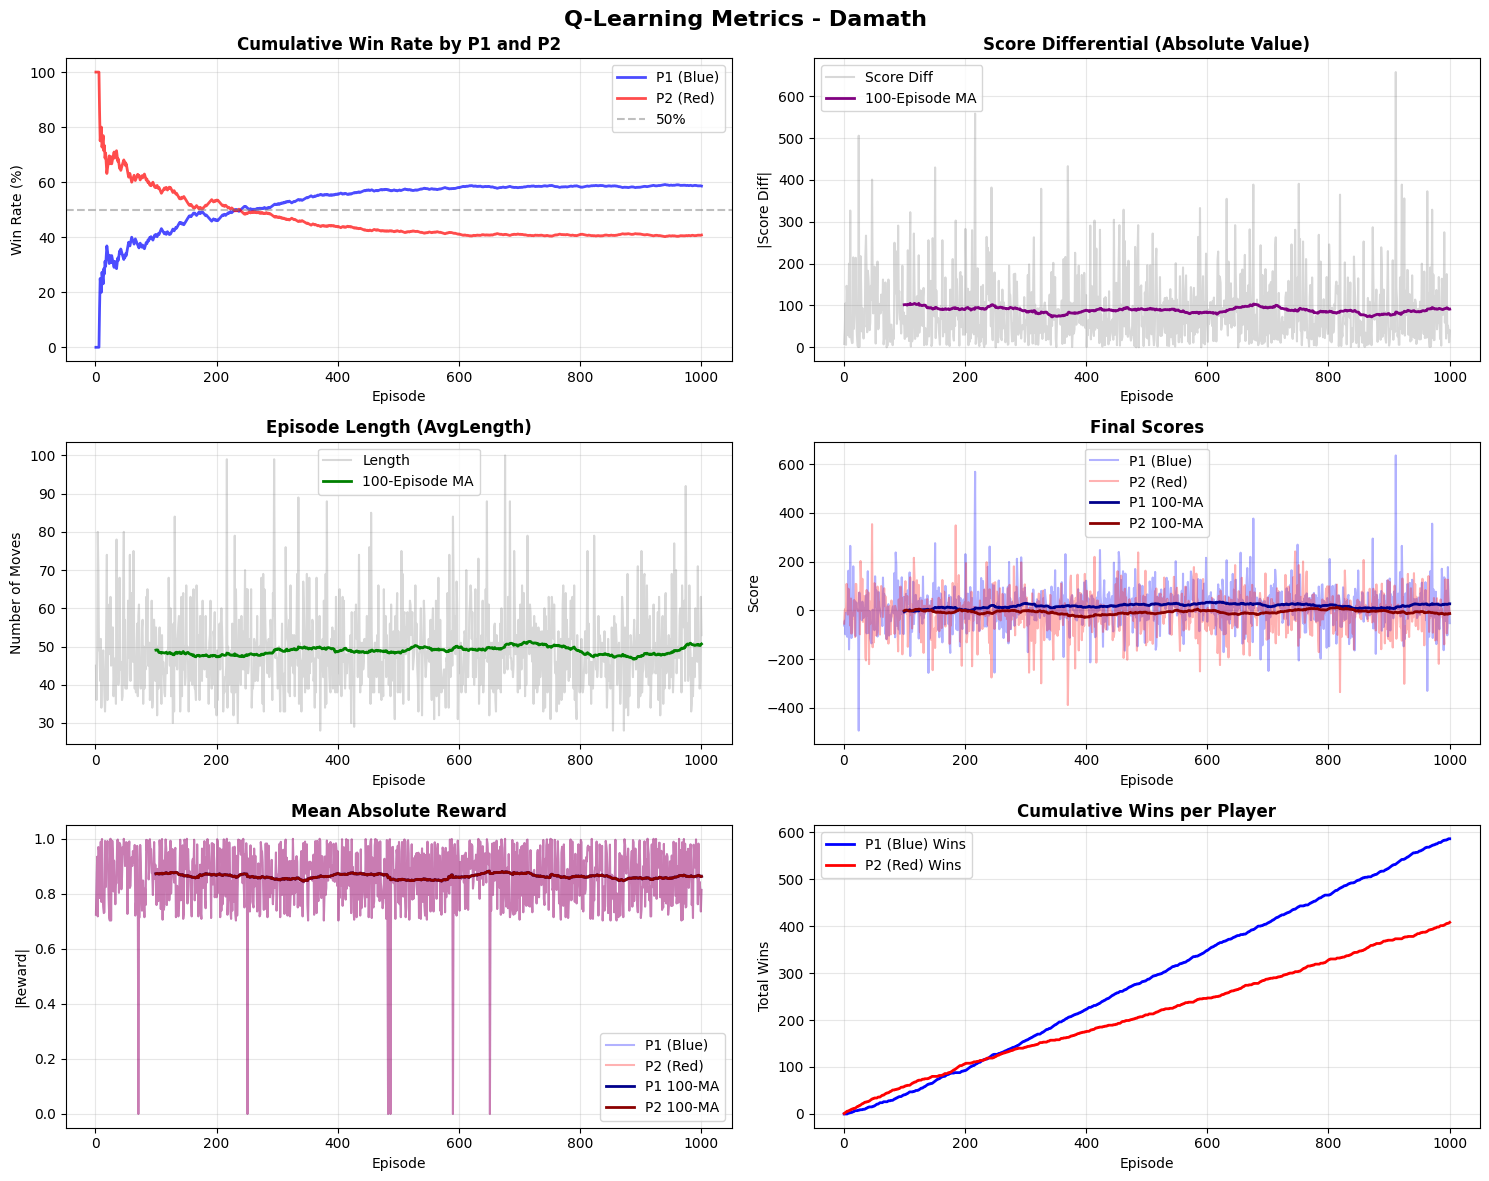

Agent saved to damath_agent_high-gamma.pkl
✅ Agent Q-table saved to 'damath_agent_high-gamma.pkl'



In [ ]:
if __name__ == "__main__":
    print("="*60)
    print("Q-LEARNING DAMATH TRAINING WITH COMPREHENSIVE METRICS")
    print("="*60)
    print("\nStarting Q-Learning training with self-play...")
    print("Agent plays as both Blue (Player 1) and Red (Player -1)\n")
    
    # Train the agent with metrics tracking
    trained_agent, training_metrics = train_qlearning_selfplay_with_metrics(
        episodes=1000,
        learning_rate=0.01,
        gamma=0.5,
        epsilon=0.2,
        K=100.0
    )
    
    print("\n" + "="*60)
    print("TRAINING COMPLETED!")
    print("="*60)
    
    # Print comprehensive training summary
    training_metrics.print_summary()
    
    # Plot training metrics
    print("\nGenerating training metrics plots...")
    training_metrics.plot_metrics(window=100)
    
    # Save trained agent Q-table
    trained_agent.save('damath_agent_low-gamma.pkl')
    print("✅ Agent Q-table saved to 'damath_agent_low-gamma.pkl'\n")


In [87]:
def verify_immediate_rewards(env, num_episodes=5):
    """
    Verify that the environment is calculating immediate rewards correctly.
    Simulates random games and logs immediate rewards for both players.
    
    Args:
        env: DamathEnv instance
        num_episodes: Number of test episodes to run
    """
    print("="*80)
    print("VERIFICATION: Environment Immediate Rewards (with Penalties)")
    print("="*80)
    
    total_reward_per_ep = {1: [], -1: []}
    capture_moves = 0
    promotion_moves = 0
    total_moves = 0
    
    for ep in range(num_episodes):
        env = DamathEnv(rows=8, cols=8)
        episode_rewards = {1: [], -1: []}
        
        print(f"\n📍 Episode {ep + 1}:")
        print("-" * 80)
        
        move_count = 0
        while not env.game_over():
            player = env.to_move
            moves = env.generate_all_moves(player)
            
            if not moves:
                break
            
            # Random move
            move = random.choice(moves)
            
            # Apply move and get immediate rewards for both players
            rewards = env.apply_move_with_penalties(move)
            episode_rewards[1].append(rewards[1])
            episode_rewards[-1].append(rewards[-1])
            total_moves += 1
            move_count += 1
            
            # Track move types
            if len(move.captures) > 0:
                capture_moves += 1
            if move.promotes:
                promotion_moves += 1
            
            # Log first few moves
            if move_count <= 3:
                move_type = "Capture" if len(move.captures) > 0 else "Regular"
                promoted = " + PROMOTION" if move.promotes else ""
                print(f"  Move {move_count}: {move_type}{promoted} (Player {player})")
                print(f"    P1 Reward: {rewards[1]:+.4f} | P2 Reward: {rewards[-1]:+.4f}")
        
        total_p1 = sum(episode_rewards[1])
        total_p2 = sum(episode_rewards[-1])
        total_reward_per_ep[1].append(total_p1)
        total_reward_per_ep[-1].append(total_p2)
        print(f"  Total Episode Rewards - P1: {total_p1:+.4f} | P2: {total_p2:+.4f}")
    
    print(f"\n{'='*80}")
    print("SUMMARY:")
    print("-" * 80)
    print(f"  Total moves: {total_moves}")
    print(f"  Capture moves: {capture_moves} ({100*capture_moves/total_moves:.1f}%)")
    print(f"  Promotion moves: {promotion_moves} ({100*promotion_moves/total_moves:.1f}%)")
    print()
    print(f"  Player 1 (Blue):")
    print(f"    Avg reward per episode: {np.mean(total_reward_per_ep[1]):+.4f}")
    print(f"    Avg reward per move: {sum(total_reward_per_ep[1])/total_moves:+.4f}")
    print()
    print(f"  Player 2 (Red):")
    print(f"    Avg reward per episode: {np.mean(total_reward_per_ep[-1]):+.4f}")
    print(f"    Avg reward per move: {sum(total_reward_per_ep[-1])/total_moves:+.4f}")
    print("="*80)
    
    # Check if rewards are non-zero
    all_rewards = total_reward_per_ep[1] + total_reward_per_ep[-1]
    if np.mean(all_rewards) != 0:
        print("✅ RESULT: Environment IS calculating immediate rewards with penalties!")
    else:
        print("⚠️  WARNING: Average rewards are zero. Check reward_config!")


def debug_qtable_states(agent, env=None, num_states=10):
    """
    Debug function to inspect the first N states in the Q-table.
    Shows board state, available actions, and Q-values.
    
    Args:
        agent: Trained QLearner agent with populated Q-table
        env: Optional DamathEnv to use for operator board display
        num_states: Number of states to inspect (default: 10)
    """
    print("="*80)
    print(f"Q-TABLE DEBUGGING: Inspecting first {num_states} states")
    print("="*80)
    
    if not agent.Q:
        print("⚠️  Q-table is empty!")
        return
    
    states_inspected = 0
    q_value_stats = []
    
    for state_key, actions_dict in agent.Q.items():
        if states_inspected >= num_states:
            break
        
        print(f"\n{'='*80}")
        print(f"STATE #{states_inspected + 1} | Total Actions: {len(actions_dict)}")
        print(f"{'='*80}")
        
        # Unpack state information
        to_move, pieces_tuple = state_key
        player_str = "🔵 Blue (P1)" if to_move == 1 else "🔴 Red (P2)"
        print(f"Player to Move: {player_str}")
        print(f"Pieces on Board: {len(pieces_tuple)}")
        
        # Reconstruct the board for visualization
        print("\n📋 Board State:")
        print("-" * 80)
        
        # Create board representation
        board = [["  ·  " for _ in range(8)] for _ in range(8)]
        
        # Place pieces
        piece_positions = {}
        for pos, player, value, is_dama in pieces_tuple:
            r, c = pos
            symbol = "🔵" if player == 1 else "🔴"
            dama_mark = "K" if is_dama else " "
            board[r][c] = f"{symbol}{dama_mark}{value:+2d}"
            piece_positions[pos] = (player, value, is_dama)
        
        # Print board with coordinates
        print("     " + "  ".join([f" {x} " for x in range(8)]))
        print("     " + "+---" * 8 + "+")
        for r in range(8):
            row_str = " | ".join(board[r])
            print(f"  {r}  | {row_str} |")
        print("     " + "+---" * 8 + "+")
        print("     " + "  ".join([f" {x} " for x in range(8)]))
        
        # Display Q-values for actions
        print(f"\n📊 Top Actions by Q-Value:")
        print("-" * 80)
        
        sorted_actions = sorted(actions_dict.items(), key=lambda x: x[1], reverse=True)
        q_value_stats.extend([q for _, q in sorted_actions])
        
        for idx, (action_key, q_value) in enumerate(sorted_actions[:5], 1):
            path, captures = action_key
            
            # Format move description
            start = path[0]
            end = path[-1]
            move_type = "CAPTURE" if captures else "MOVE"
            
            # Get piece info
            if start in piece_positions:
                player, value, is_dama = piece_positions[start]
                piece_info = f"P{value:+2d}{'K' if is_dama else ' '}"
            else:
                piece_info = "???"
            
            move_desc = f"[{piece_info}] ({start[1]},{start[0]}) → ({end[1]},{end[0]})"
            
            # Capture info
            if captures:
                capture_values = sum(pos_info[1] for pos, pos_info in piece_positions.items() 
                                    if pos in [c for c in captures])
                move_desc += f" | CAP {len(captures)} pieces (value: {capture_values:+d})"
            
            q_color = "+" if q_value > 0 else "-" if q_value < 0 else "0"
            print(f"  {idx}. {move_type}: {move_desc}")
            print(f"     [{q_color}] Q = {q_value:+.6f}")
        
        if len(sorted_actions) > 5:
            print(f"  ... and {len(sorted_actions) - 5} more actions")
        
        # Show best action
        best_action, best_q = sorted_actions[0]
        best_path, best_captures = best_action
        print(f"\n⭐ BEST ACTION:")
        print(f"   Move: ({best_path[0][1]},{best_path[0][0]}) → ({best_path[-1][1]},{best_path[-1][0]})")
        print(f"   Q-Value: {best_q:+.6f} {'(POSITIVE - good strategy)' if best_q > 0 else '(NEGATIVE - avoid)' if best_q < 0 else '(NEUTRAL)'}")
        if best_captures:
            print(f"   Captures: {len(best_captures)} piece(s)")
        
        states_inspected += 1
    
    # Statistics
    print(f"\n{'='*80}")
    print("Q-VALUE STATISTICS:")
    print("-" * 80)
    if q_value_stats:
        print(f"  Min Q-value:    {min(q_value_stats):+.6f}")
        print(f"  Max Q-value:    {max(q_value_stats):+.6f}")
        print(f"  Mean Q-value:   {np.mean(q_value_stats):+.6f}")
        print(f"  Std Q-value:    {np.std(q_value_stats):+.6f}")
        print(f"  Median Q-value: {np.median(q_value_stats):+.6f}")
    print(f"\n  Total states inspected: {states_inspected}")
    print(f"  Total states in Q-table: {len(agent.Q)}")
    print(f"  Total state-action pairs: {sum(len(actions) for actions in agent.Q.values())}")
    print("="*80)


def check_reward_config(env):
    """
    Display the current reward configuration of the environment.
    
    Args:
        env: DamathEnv instance
    """
    print("\n" + "="*80)
    print("ENVIRONMENT REWARD CONFIGURATION:")
    print("="*80)
    
    config = env.reward_config
    
    print("\nIMMEDIATE REWARDS (during gameplay):")
    print("-" * 80)
    immediate_keys = ['capture_multiplier', 'promotion_bonus', 'dama_bonus']
    for key in immediate_keys:
        if key in config:
            print(f"  {key:.<40} {config[key]:+.2f}")
    
    print("\nPENALTIES (when pieces captured):")
    print("-" * 80)
    penalty_keys = ['piece_loss_penalty', 'dama_loss_penalty']
    for key in penalty_keys:
        if key in config:
            print(f"  {key:.<40} {config[key]:+.2f}")
    
    print("="*80 + "\n")


def get_agent_stats(agent):
    """
    Get and display comprehensive statistics about the trained agent.
    
    Args:
        agent: Trained QLearner agent
    """
    print("\n" + "="*80)
    print("AGENT TRAINING STATISTICS:")
    print("="*80)
    
    stats = agent.get_stats()
    print(f"  Total states explored:        {stats['total_states']}")
    print(f"  Total state-action pairs:     {stats['total_q_entries']}")
    print(f"  Total Q-value updates:        {stats['total_updates']}")
    print(f"  Avg actions per state:        {stats['avg_q_per_state']:.2f}")
    print(f"\n  Learning rate:                {agent.learning_rate}")
    print(f"  Discount factor (gamma):      {agent.gamma}")
    print(f"  Exploration rate (epsilon):   {agent.epsilon}")
    
    print("="*80 + "\n")

check_reward_config(env)

verify_immediate_rewards(env, num_episodes=5)

debug_qtable_states(trained_agent, num_states=20)

get_agent_stats(trained_agent)


ENVIRONMENT REWARD CONFIGURATION:

IMMEDIATE REWARDS (during gameplay):
--------------------------------------------------------------------------------
  capture_multiplier...................... +1.00
  promotion_bonus......................... +10.00
  dama_bonus.............................. +5.00

PENALTIES (when pieces captured):
--------------------------------------------------------------------------------
  piece_loss_penalty...................... -5.00
  dama_loss_penalty....................... -15.00

VERIFICATION: Environment Immediate Rewards (with Penalties)

📍 Episode 1:
--------------------------------------------------------------------------------
  Move 1: Regular (Player 1)
    P1 Reward: +0.0000 | P2 Reward: +0.0000
  Move 2: Regular (Player -1)
    P1 Reward: +0.0000 | P2 Reward: +0.0000
  Move 3: Regular (Player 1)
    P1 Reward: +0.0000 | P2 Reward: +0.0000
  Total Episode Rewards - P1: -77.0000 | P2: -13.0000

📍 Episode 2:
--------------------------------------